#  Analyse Exploratoire (EDA)

In [5]:
!pip install wordcloud


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\MON_PC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 1. Importation des bibliothèques

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'


## 2. Chargement du dataset

In [7]:
# Charger le fichier fusionné par Sara
df = pd.read_csv('dataset_final.csv')

print(f'Nombre de lignes    : {len(df):,}')
print(f'Nombre de colonnes  : {df.shape[1]}')
print(f'Colonnes            : {list(df.columns)}')
print()


Nombre de lignes    : 44,898
Nombre de colonnes  : 5
Colonnes            : ['title', 'text', 'subject', 'date', 'label']



In [8]:
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1



## 3. Graphique de distribution Fake vs True

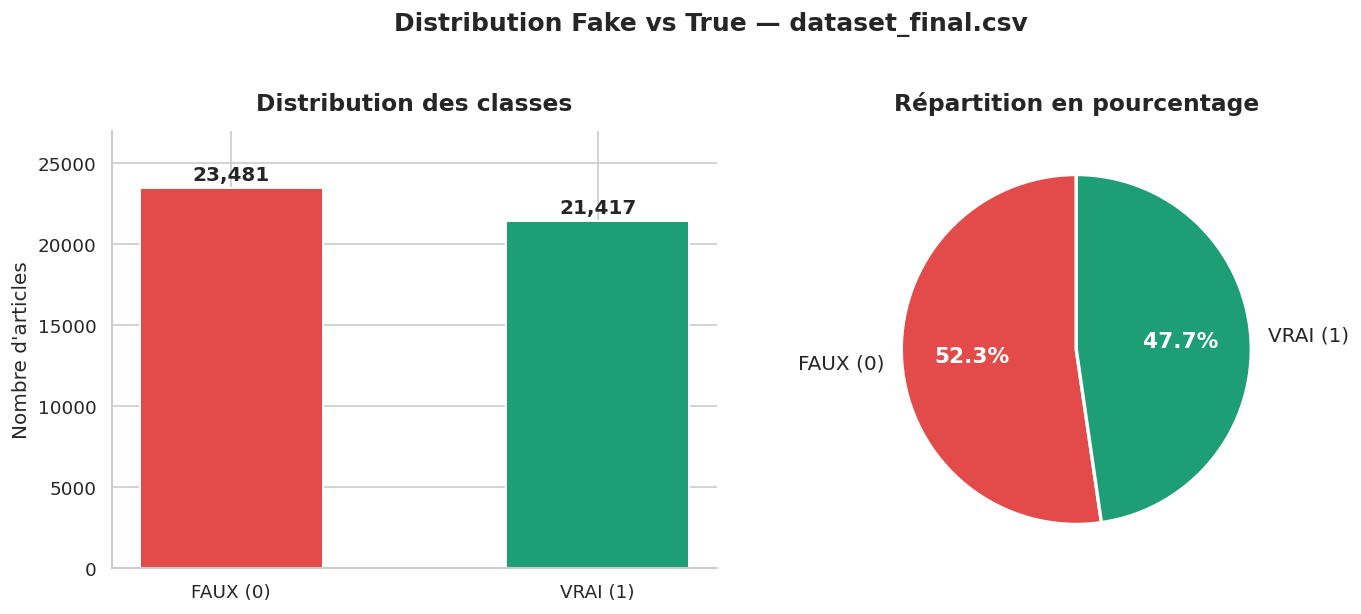

FAUX : 23,481 articles (52.3%)
VRAI : 21,417 articles (47.7%)
 Dataset bien équilibré (ratio < 2:1) → pas besoin de rééchantillonnage


In [9]:
counts = df['label'].value_counts().sort_index()
labels_names = ['FAUX (0)', 'VRAI (1)']
colors = ['#E24B4A', '#1D9E75']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Barres ---
bars = axes[0].bar(labels_names, counts.values, color=colors,
                   width=0.5, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribution des classes', fontsize=14, fontweight='bold', pad=12)
axes[0].set_ylabel('Nombre d\'articles')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(counts.values) * 1.15)
axes[0].spines[['top','right']].set_visible(False)

# --- Camembert ---
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=labels_names, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2},
    textprops={'fontsize':12}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
    at.set_color('white')
axes[1].set_title('Répartition en pourcentage', fontsize=14, fontweight='bold', pad=12)

plt.suptitle('Distribution Fake vs True — dataset_final.csv',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_distribution.png', bbox_inches='tight')
plt.show()

print(f'FAUX : {counts[0]:,} articles ({counts[0]/len(df)*100:.1f}%)')
print(f'VRAI : {counts[1]:,} articles ({counts[1]/len(df)*100:.1f}%)')
print(' Dataset bien équilibré (ratio < 2:1) → pas besoin de rééchantillonnage')

## 4. Analyse de la longueur des textes par classe

In [10]:
# Calcul des longueurs
df['len_text']  = df['text'].astype(str).str.len()
df['len_title'] = df['title'].astype(str).str.len()

# Statistiques descriptives
stats_text  = df.groupby('label')['len_text'].describe()[['mean','min','50%','max']]
stats_title = df.groupby('label')['len_title'].describe()[['mean','min','50%','max']]

stats_text.index  = ['FAUX (0)', 'VRAI (1)']
stats_title.index = ['FAUX (0)', 'VRAI (1)']

print('=== Longueur des TEXTES (en caractères) ===')
print(stats_text.round(0).astype(int).rename(columns={'50%':'médiane'}))
print()
print('=== Longueur des TITRES (en caractères) ===')
print(stats_title.round(0).astype(int).rename(columns={'50%':'médiane'}))

=== Longueur des TEXTES (en caractères) ===
          mean  min  médiane    max
FAUX (0)  2547    1     2166  51794
VRAI (1)  2383    1     2222  29781

=== Longueur des TITRES (en caractères) ===
          mean  min  médiane  max
FAUX (0)    94    8       90  286
VRAI (1)    65   26       64  133


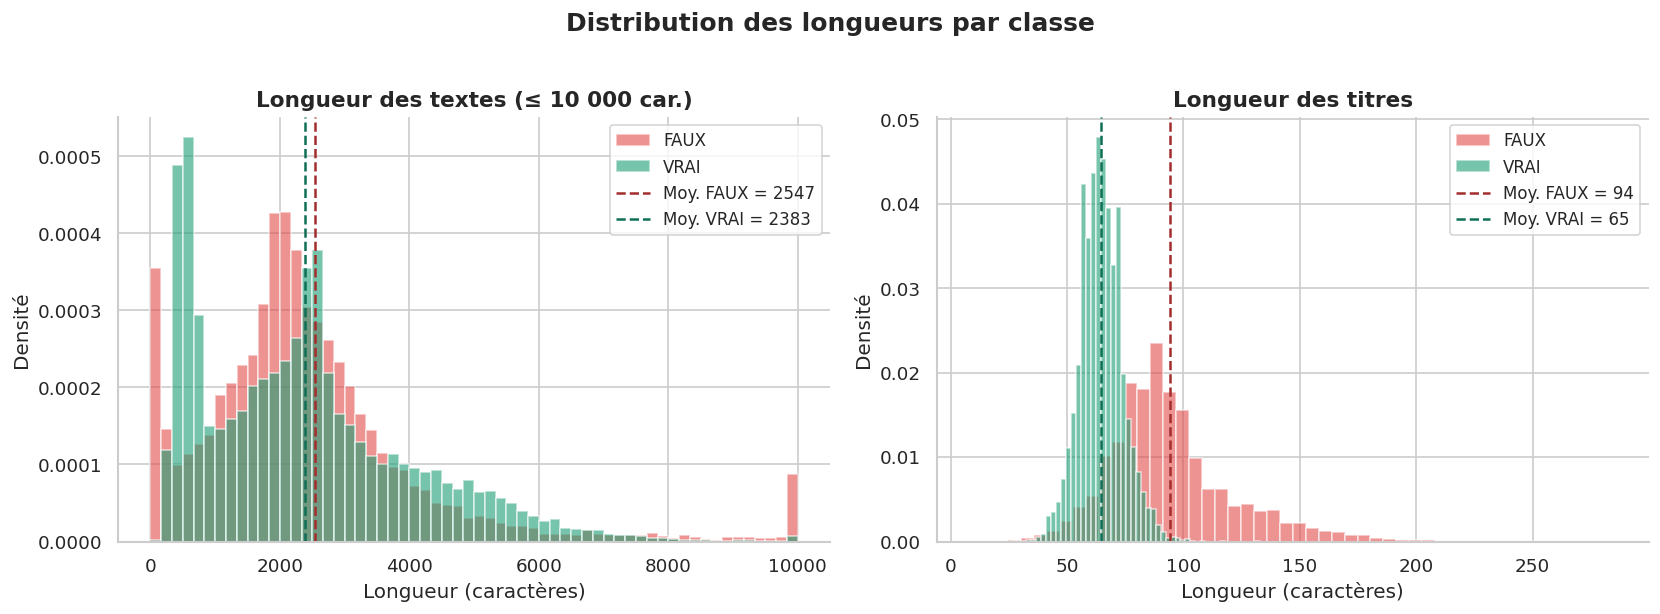

 Les titres FAUX sont 46% plus longs que les vrais → signal fort pour le modèle !


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fake_df = df[df['label'] == 0]
true_df = df[df['label'] == 1]

# --- Longueur textes ---
axes[0].hist(fake_df['len_text'].clip(upper=10000), bins=60,
             color='#E24B4A', alpha=0.6, label='FAUX', density=True)
axes[0].hist(true_df['len_text'].clip(upper=10000), bins=60,
             color='#1D9E75', alpha=0.6, label='VRAI', density=True)
axes[0].axvline(fake_df['len_text'].mean(), color='#A32D2D', linestyle='--', lw=1.5,
                label=f"Moy. FAUX = {fake_df['len_text'].mean():.0f}")
axes[0].axvline(true_df['len_text'].mean(), color='#0F6E56', linestyle='--', lw=1.5,
                label=f"Moy. VRAI = {true_df['len_text'].mean():.0f}")
axes[0].set_title('Longueur des textes (≤ 10 000 car.)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Longueur (caractères)')
axes[0].set_ylabel('Densité')
axes[0].legend(fontsize=10)
axes[0].spines[['top','right']].set_visible(False)

# --- Longueur titres ---
axes[1].hist(fake_df['len_title'], bins=50,
             color='#E24B4A', alpha=0.6, label='FAUX', density=True)
axes[1].hist(true_df['len_title'], bins=50,
             color='#1D9E75', alpha=0.6, label='VRAI', density=True)
axes[1].axvline(fake_df['len_title'].mean(), color='#A32D2D', linestyle='--', lw=1.5,
                label=f"Moy. FAUX = {fake_df['len_title'].mean():.0f}")
axes[1].axvline(true_df['len_title'].mean(), color='#0F6E56', linestyle='--', lw=1.5,
                label=f"Moy. VRAI = {true_df['len_title'].mean():.0f}")
axes[1].set_title('Longueur des titres', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Longueur (caractères)')
axes[1].set_ylabel('Densité')
axes[1].legend(fontsize=10)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Distribution des longueurs par classe', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_longueurs.png', bbox_inches='tight')
plt.show()

diff = (fake_df['len_title'].mean() - true_df['len_title'].mean()) / true_df['len_title'].mean() * 100
print(f' Les titres FAUX sont {diff:.0f}% plus longs que les vrais → signal fort pour le modèle !')

---
## 4. WordCloud des mots les plus fréquents

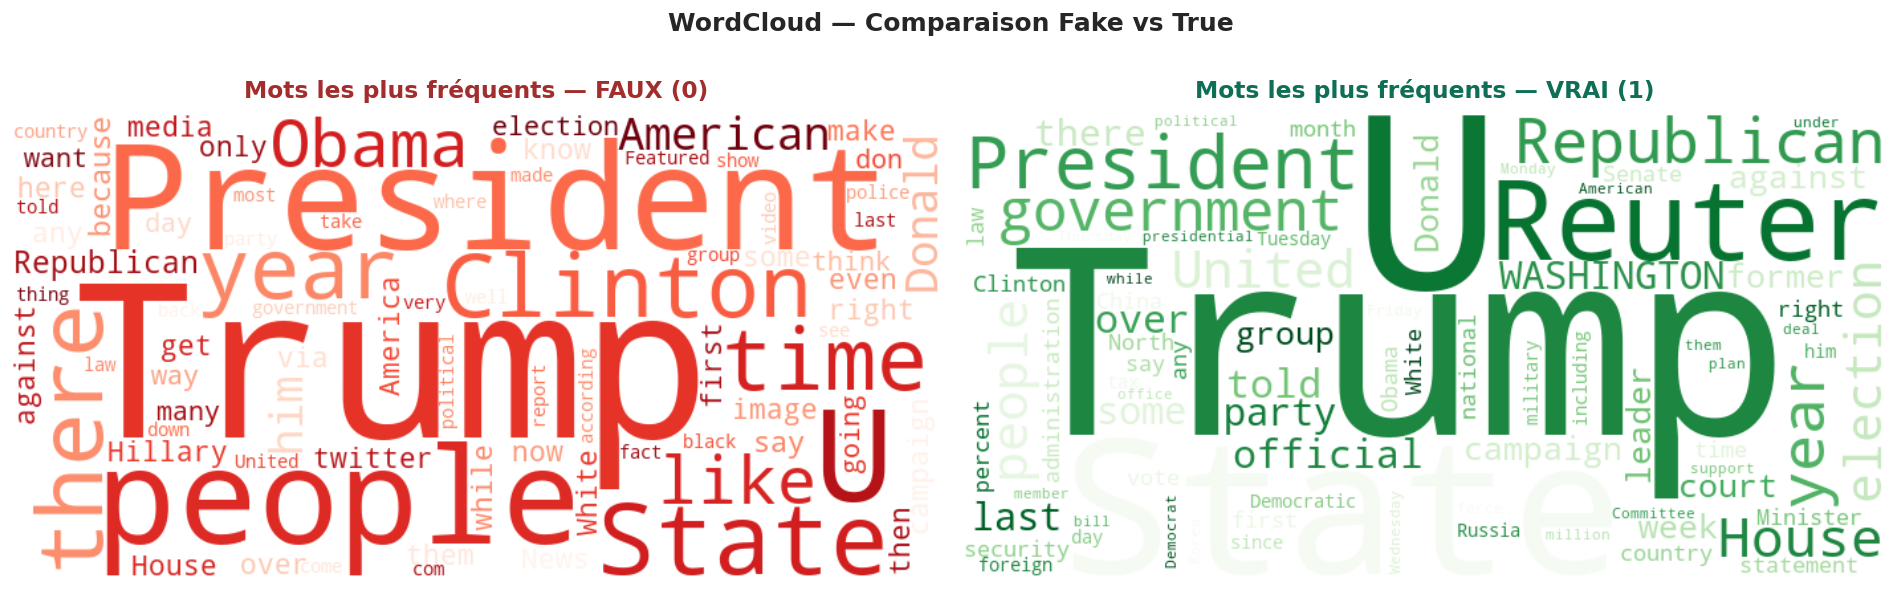

 WordClouds générés


In [12]:
# Stopwords de base (sera affiné par Meryem à l'étape suivante)
STOPWORDS = {
    'the','a','an','and','or','but','in','on','at','to','for','of','is','are',
    'was','were','be','been','being','have','has','had','do','does','did',
    'will','would','could','should','may','might','this','that','these','those',
    'it','its','as','by','from','with','he','she','they','we','you','i',
    'his','her','their','our','your','my','not','no','so','if','than',
    'about','after','before','between','into','through','during','said',
    'also','more','other','up','out','what','when','who','which','how',
    'one','two','all','new','can','just','s','t','re','ve','ll','d','m'
}

text_fake = ' '.join(df[df['label'] == 0]['text'].astype(str).tolist())
text_true = ' '.join(df[df['label'] == 1]['text'].astype(str).tolist())

wc_fake = WordCloud(
    width=700, height=350,
    background_color='white',
    stopwords=STOPWORDS,
    colormap='Reds',
    max_words=80,
    collocations=False
).generate(text_fake)

wc_true = WordCloud(
    width=700, height=350,
    background_color='white',
    stopwords=STOPWORDS,
    colormap='Greens',
    max_words=80,
    collocations=False
).generate(text_true)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Mots les plus fréquents — FAUX (0)',
                  fontsize=14, fontweight='bold', color='#A32D2D', pad=10)

axes[1].imshow(wc_true, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Mots les plus fréquents — VRAI (1)',
                  fontsize=14, fontweight='bold', color='#0F6E56', pad=10)

plt.suptitle('WordCloud — Comparaison Fake vs True',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_wordcloud.png', bbox_inches='tight')
plt.show()
print(' WordClouds générés')

---
## 5. Détecter les déséquilibres dans les données

In [13]:
print('═' * 50)
print('RAPPORT DE DÉSÉQUILIBRE DES DONNÉES')
print('═' * 50)

# 1. Déséquilibre de classes
print('\n 1. CLASSES (label)')
vc = df['label'].value_counts()
ratio = vc.max() / vc.min()
print(f'   FAUX : {vc[0]:,} articles')
print(f'   VRAI : {vc[1]:,} articles')
print(f'   Ratio max/min : {ratio:.2f}')
if ratio < 2:
    print('    Équilibré — aucune technique de rééchantillonnage nécessaire')
else:
    print('    Déséquilibre détecté — envisager SMOTE ou class_weight')

# 2. Valeurs manquantes
print('\n 2. VALEURS MANQUANTES')
missing = df.isnull().sum()
if missing.sum() == 0:
    print('    Aucune valeur manquante dans le dataset')
else:
    print(missing[missing > 0])

# 3. Doublons
print('\n 3. DOUBLONS')
dupes = df.duplicated().sum()
print(f'   Lignes dupliquées : {dupes}')
if dupes > 0:
    print('     Faut  supprimer les doublons avant entraînement')
else:
    print('    Aucun doublon détecté')

# 4. Sujets par classe
print('\n 4. RÉPARTITION PAR SUJET')
print(df.groupby(['label', 'subject']).size().reset_index(name='count').to_string(index=False))

print('\n' + '═' * 50)

══════════════════════════════════════════════════
RAPPORT DE DÉSÉQUILIBRE DES DONNÉES
══════════════════════════════════════════════════

 1. CLASSES (label)
   FAUX : 23,481 articles
   VRAI : 21,417 articles
   Ratio max/min : 1.10
    Équilibré — aucune technique de rééchantillonnage nécessaire

 2. VALEURS MANQUANTES
    Aucune valeur manquante dans le dataset

 3. DOUBLONS
   Lignes dupliquées : 209
     Faut  supprimer les doublons avant entraînement

 4. RÉPARTITION PAR SUJET
 label         subject  count
     0 Government News   1570
     0     Middle-east    778
     0            News   9050
     0         US_News    783
     0       left-news   4459
     0        politics   6841
     1    politicsNews  11272
     1       worldnews  10145

══════════════════════════════════════════════════


In [14]:
# Suppression des lignes dupliquées avant l'entraînement
df = df.drop_duplicates()
print(f"Après suppression des doublons : {len(df)} lignes restantes")

Après suppression des doublons : 44689 lignes restantes


---
## 6. Graphique des sujets par classe

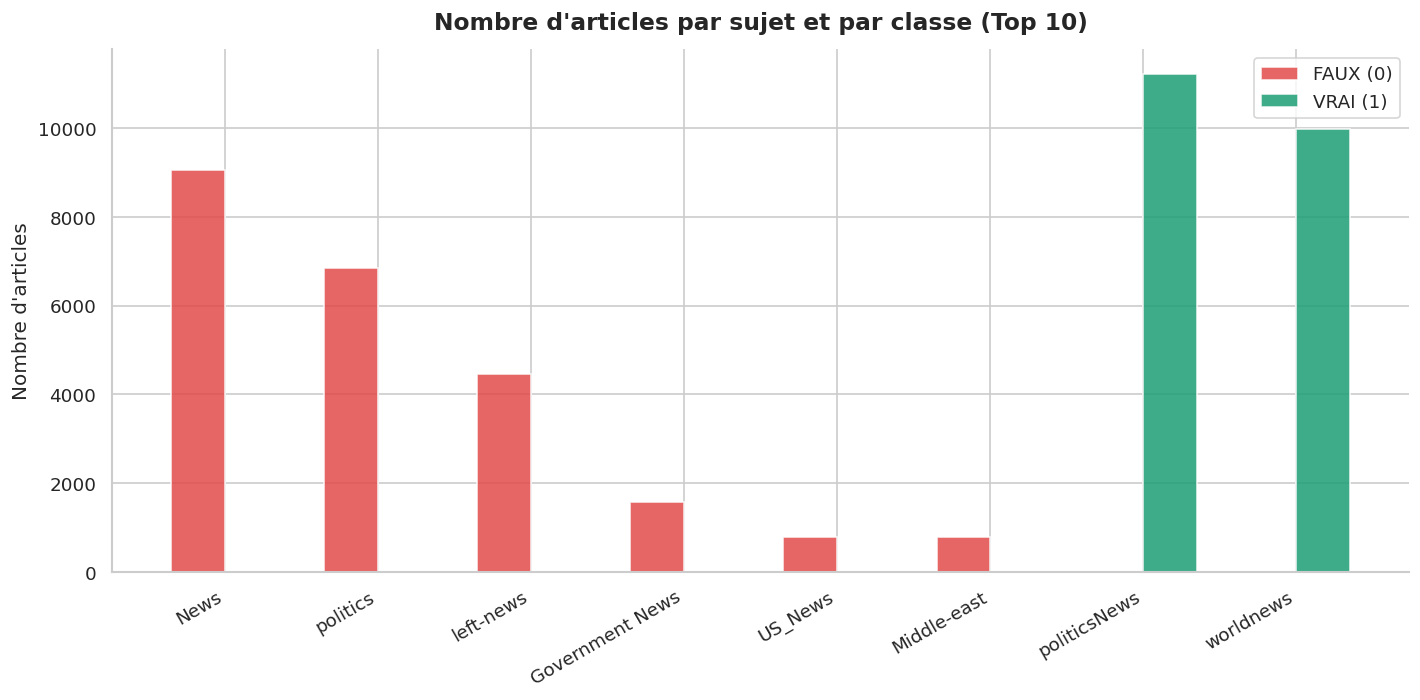

Graphique sujets généré


In [15]:
subject_counts = df.groupby(['subject', 'label']).size().unstack(fill_value=0)
subject_counts = subject_counts.sort_values(by=subject_counts.columns.tolist(), ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(subject_counts))
width = 0.35

if 0 in subject_counts.columns:
    bars1 = ax.bar([i - width/2 for i in x], subject_counts[0], width,
                   label='FAUX (0)', color='#E24B4A', alpha=0.85, edgecolor='white')
if 1 in subject_counts.columns:
    bars2 = ax.bar([i + width/2 for i in x], subject_counts[1], width,
                   label='VRAI (1)', color='#1D9E75', alpha=0.85, edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(subject_counts.index, rotation=30, ha='right', fontsize=11)
ax.set_title('Nombre d\'articles par sujet et par classe (Top 10)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Nombre d\'articles')
ax.legend(fontsize=11)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig4_sujets.png', bbox_inches='tight')
plt.show()
print('Graphique sujets généré')

---
## 7. Nettoyage du texte

Cette section effectue le prétraitement des textes avant modélisation :
1. **Suppression des liens URL**
2. **Suppression de la ponctuation & des caractères spéciaux**
3. **Mise en minuscules**
4. **Suppression des stopwords**


In [16]:
import re
import string
import nltk

# Télécharger les stopwords NLTK (une seule fois)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

print(' Bibliothèques de nettoyage importées')

 Bibliothèques de nettoyage importées


In [17]:
# Stopwords anglais (NLTK) + quelques ajouts spécifiques au dataset
STOP_WORDS = set(stopwords.words('english')) | {
    'said', 'would', 'could', 'also', 'one', 'two', 'three',
    'us', 'reuters', 'news', 'u', 's'
}

def clean_text(text: str) -> str:
    """Pipeline complet de nettoyage d'un texte."""

    # 1  Supprimer les liens URL  (http/https/www)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 2  Enlever la ponctuation & les caractères spéciaux
    # On conserve uniquement les lettres et les espaces
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # 3 Mettre tout en minuscules
    text = text.lower()

    # 4  Supprimer les stopwords
    tokens = text.split()
    tokens = [tok for tok in tokens if tok not in STOP_WORDS and len(tok) > 1]

    return ' '.join(tokens)

print(' Fonction clean_text() définie')

 Fonction clean_text() définie


In [18]:
# ── Test rapide sur un exemple ──────────────────────────────────────────────
sample = (
    "Breaking News! Visit https://fakenews.com/article?id=123 "
    "for more info. The U.S. President said: 'This is GREAT!!!' "
    "— @user #trending 2024."
)

cleaned = clean_text(sample)
print('Texte original :')
print(' ', sample)
print()
print('Texte nettoyé  :')
print(' ', cleaned)

Texte original :
  Breaking News! Visit https://fakenews.com/article?id=123 for more info. The U.S. President said: 'This is GREAT!!!' — @user #trending 2024.

Texte nettoyé  :
  breaking visit info president great user trending


In [19]:
# ── Application au dataset ──────────────────────────────────────────────────
print('Nettoyage en cours …')

df['text_clean']  = df['text'].astype(str).apply(clean_text)
df['title_clean'] = df['title'].astype(str).apply(clean_text)

print(f' Colonnes créées : text_clean, title_clean')
print(f'   Lignes traitées : {len(df):,}')

# Aperçu avant / après
print('\n── Aperçu (text) ──────────────────────────────────────────')
for _, row in df.head(3).iterrows():
    print(f'  AVANT  : {str(row["text"])[:120]}')
    print(f'  APRÈS  : {str(row["text_clean"])[:120]}')
    print()

Nettoyage en cours …
 Colonnes créées : text_clean, title_clean
   Lignes traitées : 44,689

── Aperçu (text) ──────────────────────────────────────────
  AVANT  : 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing
  APRÈS  : st century wire says ben stein reputable professor pepperdine university hollywood fame appearing tv shows films ferris 

  AVANT  : WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security 
  APRÈS  : washington president donald trump removed chief strategist steve bannon national security council wednesday reversing co

  AVANT  : (Reuters) - Puerto Rico Governor Ricardo Rossello said on Wednesday he expected the federal government to waive the Jone
  APRÈS  : puerto rico governor ricardo rossello wednesday expected federal government waive jones act lift restrictions ships prov



In [22]:
# ── Statistiques : réduction de longueur ────────────────────────────────────
df['len_text_clean']  = df['text_clean'].str.split().str.len()
df['len_title_clean'] = df['title_clean'].str.split().str.len()
df['len_text_words']  = df['text'].astype(str).str.split().str.len()
df['len_title_words'] = df['title'].astype(str).str.split().str.len()

print('═' * 55)
print('STATISTIQUES — NETTOYAGE DU TEXTE')
print('═' * 55)

red_text  = (1 - df['len_text_clean'].mean()  / df['len_text_words'].mean())  * 100
red_title = (1 - df['len_title_clean'].mean() / df['len_title_words'].mean()) * 100

print(f'  Mots moy. text  avant nettoyage : {df["len_text_words"].mean():.0f}')
print(f'  Mots moy. text  après nettoyage : {df["len_text_clean"].mean():.0f}  (−{red_text:.1f}%)')
print()
print(f'  Mots moy. title avant nettoyage : {df["len_title_words"].mean():.0f}')
print(f'  Mots moy. title après nettoyage : {df["len_title_clean"].mean():.0f}  (−{red_title:.1f}%)')
print('═' * 55)

# Sauvegarde du dataset nettoyé
df.to_csv('dataset_clean.csv', index=False)
print('dataset_clean.csv sauvegardé')
print('─' * 55)
print('→ Prochaine étape : Vectorisation (TF-IDF / Word2Vec)')
print('─' * 55)

═══════════════════════════════════════════════════════
STATISTIQUES — NETTOYAGE DU TEXTE
═══════════════════════════════════════════════════════
  Mots moy. text  avant nettoyage : 405
  Mots moy. text  après nettoyage : 223  (−44.9%)

  Mots moy. title avant nettoyage : 12
  Mots moy. title après nettoyage : 9  (−26.2%)
═══════════════════════════════════════════════════════
dataset_clean.csv sauvegardé
───────────────────────────────────────────────────────
→ Prochaine étape : Vectorisation (TF-IDF / Word2Vec)
───────────────────────────────────────────────────────
